# Example notebook of a Variant QC analysis

The present notebook serves as a guide of how use the `IDEAL-GENOM-QC` library to perform a variant quality control. We intend to show a possible use, because each user can adapt it to its particular needs.

In this notebook the procedure to perform the variant quality control is more detailed so the user can get a deeper understanding of all the steps executed in this part of the pipeline.

Let us import the required libraries.

In [15]:
import sys
import os

import pandas as pd

from pathlib import Path

# add parent directory to path
library_path = os.path.abspath('..')
if library_path not in sys.path:
    sys.path.append(library_path)

library_path = Path(library_path)

from ideal_genom.qc.variant_qc import VariantQC, VariantQCReport, VariantQCCleanUp

In the next cell the path variables associated with the project are set.

In [16]:
DATA_PATH = library_path / 'ideal_genom' / 'data'

example_data = DATA_PATH / 'example_data'
inputData    = example_data / 'inputData'
ouputData    = example_data / 'outputData'

input_path = inputData
input_name = 'SAS_example'
output_path= ouputData
output_name= '1KG_GRCh38_variant_qc'

In the next cell we define a dictionary containing the parameters to execute the variant QC pipeline.

The explanation of the parameters is the following:

1. `chr_y`: identifier of Y chromosome in plink binary files.
2. `miss_data_rate`: Missing data rate threshold for variants.
3. `diff_genotype_rate`: P-value threshold for the case/control differential missingness test.
4. `geno`: Parameter `--geno` of **PLINK1.9**, maximum per-variant missing genotype rate.
5. `hwe`: Parameter `--hwe` of **PLINK1.9**. Note there is no separate HWE *check* step that produces its own fail list — the threshold is applied directly during the final filtering step (`execute_drop_variants`), together with `maf` and `geno`.
6. `maf`: Parameter `--maf` of **PLINK1.9**.

In [17]:
variant_params = {
    'chr_y': 24,
    'miss_data_rate': 0.2,
    'diff_genotype_rate': 1e-5,
    'geno': 0.1,
    'maf': 5e-8,
    'hwe': 5e-8,
}

Initialize the class `VariantQC`.

In [18]:
variant = VariantQC(
    input_path=input_path,
    input_name=input_name,
    output_path=output_path,
    output_name=output_name,
)

Execute the pipeline steps of the variant quality control. `execute_variant_qc_pipeline()` runs every QC step in order (missing data rate, case/control differential missingness, fail-variant aggregation), and drops the failing variants, producing cleaned `PLINK` files in `variant.clean_dir`.

The pipeline shells out to PLINK many times, which prints a lot of console text; we capture it into `variant_qc_log` to keep the notebook readable — run `variant_qc_log.show()` in a new cell if you need to inspect it.

In [19]:
log_path = "logs/variant_qc.log"

with open(log_path, "w") as f:
    old_stdout_fd = os.dup(1)
    old_stderr_fd = os.dup(2)
    
    try:
        os.dup2(f.fileno(), 1)
        os.dup2(f.fileno(), 2)

        variant.execute_variant_qc_pipeline(variant_params=variant_params)
    finally:
        os.dup2(old_stdout_fd, 1)
        os.dup2(old_stderr_fd, 2)
        os.close(old_stdout_fd)
        os.close(old_stderr_fd)

print(f"Pipeline complete. Log saved to: {log_path}")

2026-06-26 12:00:45,200 - INFO - Identifying markers with excessive missing rate...
2026-06-26 12:00:45,201 - INFO - Executing: plink2 --bfile /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/inputData/SAS_example --missing --filter-males --chr 24 --out /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/outputData/variant_qc_results/1KG_GRCh38_variant_qc-missing-males-only --memory 33297 --threads 30
2026-06-26 12:00:45,210 - INFO - Command completed successfully
2026-06-26 12:00:45,210 - INFO - Executing: plink2 --bfile /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/inputData/SAS_example --missing --not-chr 24 --out /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/outputData/variant_qc_results/1KG_GRCh38_variant_qc-missing-not-y --memory 33297 --threads 30
2026-06-26 12:00:45,225 - INFO - Command completed successfully
2026-06-26 12:00:45,226 - INFO - Identifying markers with different genotype call rates between cases and controls...
2026-0

Compute missing data rate for males and females.
Case/control nonrandom missingness test.
Get variants that failed quality control.


2026-06-26 12:00:45,499 - INFO - Removing markers failing quality control...
2026-06-26 12:00:45,500 - INFO - Executing: plink --bfile /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/inputData/SAS_example --exclude /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/outputData/variant_qc_results/fail_markers/fail_markers.txt --autosome --maf 5e-08 --hwe 5e-08 midp --geno 0.1 --make-bed --out /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/outputData/variant_qc_results/clean_files/1KG_GRCh38_variant_qc
2026-06-26 12:00:45,531 - INFO - Command completed successfully


Drop variants that failed quality control.
Pipeline complete. Log saved to: logs/variant_qc.log


In [20]:
print(f"Variant QC pipeline completed. Clean PLINK files written to: {variant.clean_dir}")

Variant QC pipeline completed. Clean PLINK files written to: /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/outputData/variant_qc_results/clean_files


**Note:** `execute_variant_qc_pipeline()` already performs the full pipeline end-to-end, including aggregating all QC failures (`get_fail_variants()`) and removing them (`execute_drop_variants()`). The cells below are for *inspecting and customizing* the resulting reports — they do not need to repeat the failure aggregation or variant dropping.

In [21]:
report = VariantQCReport(
    output_path=variant.plots_dir
)

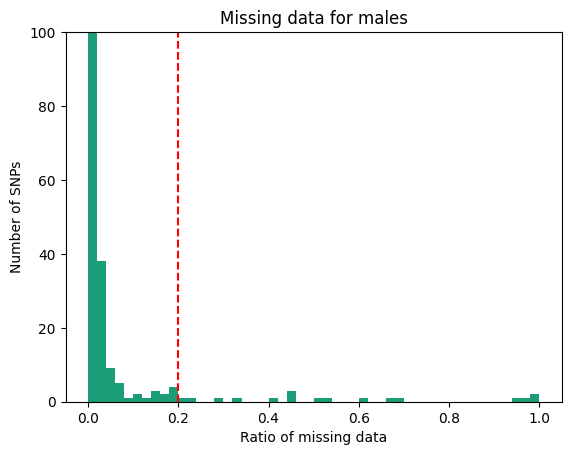

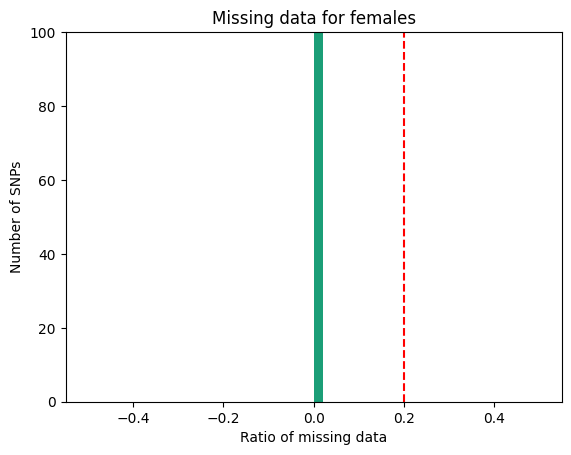

In [22]:
report.report_variant_qc(
    missing_data_rate_male  =variant.males_missing_data,
    missing_data_rate_female=variant.females_missing_data,
    y_axis_cap              =100,
    missing_data_threshold  =variant_params['miss_data_rate'],
)

Here a small dashboard with a report of the per-variant missing data rate is shown, split by sex (the Y chromosome is only present in males, so missingness is computed separately to avoid confounding). The cap on the Y-axis can be selected without re-running the whole pipeline.

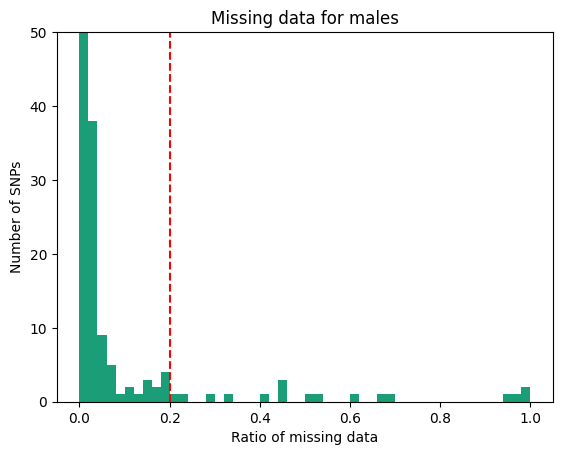

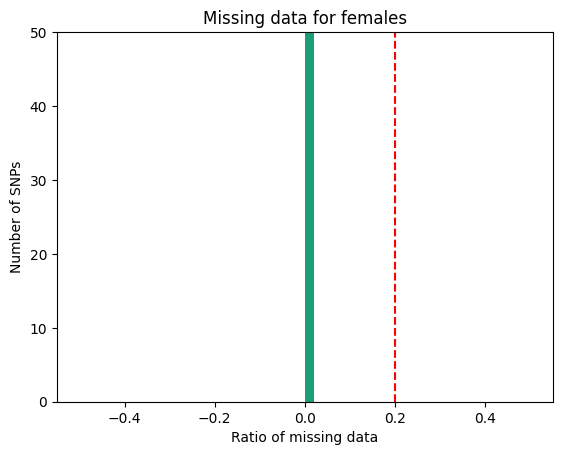

In [23]:
# Regenerate the missing-data plots alone, e.g. with a different y-axis cap
report.report_variant_qc(
    missing_data_rate_male  =variant.males_missing_data,
    missing_data_rate_female=variant.females_missing_data,
    y_axis_cap              =50,
    missing_data_threshold  =variant_params['miss_data_rate'],
)

All QC failures were already aggregated by `get_fail_variants()` inside `execute_variant_qc_pipeline()`, which wrote `fail_markers.txt` and `variant_qc_summary.tsv` to disk. Let's load them to inspect how many variants failed each check.

In [24]:
variant_summary = pd.read_csv(variant.results_dir / 'variant_qc_summary.tsv', sep='\t')
fail_markers = pd.read_csv(variant.fails_dir / 'fail_markers.txt', header=None, names=['SNP'])

In [25]:
variant_summary

,Failure,count
0,Missing data rate on males,17
1,Duplicated SNPs,-16
2,Total,1


In [26]:
print('Unique variants failing QC:', fail_markers.shape[0])

Unique variants failing QC: 1


The failing variants were already dropped by `execute_drop_variants()` inside the pipeline run above (together with the `maf`/`geno`/`hwe` thresholds). The cleaned `PLINK` files are available at the path below.

In [27]:
clean_files = variant.clean_dir / variant.output_name
print(f'Clean PLINK files (variants failing QC removed): {clean_files}')

Clean PLINK files (variants failing QC removed): /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/outputData/variant_qc_results/clean_files/1KG_GRCh38_variant_qc


Some intermediate files are deleted to save space.

In [28]:
cleanup = VariantQCCleanUp(output_path=variant.results_dir)
cleanup.clean_all()

2026-06-26 12:00:46,420 - INFO - Cleaning up intermediate files from output directory
2026-06-26 12:00:46,420 - INFO - Deleted: /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/outputData/variant_qc_results/1KG_GRCh38_variant_qc-missing-males-only.vmiss
2026-06-26 12:00:46,421 - INFO - Deleted: /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/outputData/variant_qc_results/1KG_GRCh38_variant_qc-missing-not-y.vmiss
2026-06-26 12:00:46,421 - INFO - Deleted: /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/outputData/variant_qc_results/1KG_GRCh38_variant_qc-missing-not-y.smiss
2026-06-26 12:00:46,421 - INFO - Deleted: /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/outputData/variant_qc_results/1KG_GRCh38_variant_qc-missing-males-only.smiss
2026-06-26 12:00:46,421 - INFO - Deleted: /home/luis/CGE/ideal-genom-qc/ideal_genom/data/example_data/outputData/variant_qc_results/1KG_GRCh38_variant_qc-case-control-missing.missing
